# Calibrate-Orbitrap-SO4-M0

A notebook to calibrate internal ESI-Orbitrap MS isotopologue delta values of samples, using the measured and true values of isotope standards analysed in a sequence.

Accepts either a single M0 sequence.

Uses a Monte-Carlo approach (peturbation of input data by their uncertainties and c. 1000 repeat calculations) to estimate mean and error of each sample's true $\delta$- and $\Delta$-values. 

All errors are ±$1\sigma$

Calibrated data are reported in an excel file.

### Inputs:
- results_'YYYY-MM-DD'.xlsx file containing internal isotopologue measurements of a sequence of samples and standards. Files must be in a subfolder named 'M0' or 'noM0'.
- references_nitrate.xlsx file, with referenced isotope values of the standards measured in the sequence.

### Output:
- 'current-dir'-calibrated-'YYYY-MM-DD'.xlsx, containing sheets for uncalibrated small $\delta$, calibrated small $\delta$, a synthesis of the final $\delta$- and $\Delta$-values, and calibration metadata.

In [76]:
import os
import numpy as np
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import os
from datetime import datetime
current_datetime = datetime.now()
current_date_string = current_datetime.strftime("%Y-%m-%d")


### Find and import Orbitrap data, merge files, drop outlying rows
For automatic identification of files, they must be in appropriate 'M0' or 'noM0' subfolders, and be named 'results.....xlsx'

In [77]:
# automatically select files
paths=[]
n_M0=0; n_noM0=0
# detect folders on path
folders = [folder for folder in os.listdir() if folder in ('m0','nom0','M0','noM0')]
for folder in folders:
    # select files within folder
    files = [file for file in sorted(os.listdir(folder)) if file.startswith('results') and file.endswith('.xlsx')]
    if len(files)==1:
        file = files[0]
        print('File',file,'found in folder',folder)
    elif len(files)>1.5:
        file = files[-1]
        print('File',file,'found in folder',folder,'(last file alphabetically selected from multiple files)')
    else:
        print('No file found in',folder)
    paths+=[os.path.join(folder,file)]
    # count instances of M0 or noM0 in folder names
    if folder.endswith(('nom0','noM0')):
        n_noM0+=1
    if folder.endswith(('m0','M0')):
        n_M0+=1
# automatically select data type
if n_noM0>0.5 and n_M0>0.5:
    data_type='M0+noM0'
    print('Data type =',data_type)
elif n_M0>0.5:
    data_type='M0-only'
    print('Data type =',data_type)
else:
    print('error selecting data type')
    
### Or manually input filename
# paths = ['250203_DC-2011-2_HSO4_noM0/results_2025-02-08.xlsx',
#          '250131_DC-2011-2_HSO4_M0/results_2025-02-08.xlsx']
### Or manually input data type
# data_type = 'M0-only'
# data_type = 'M0+noM0'

data=pd.DataFrame()
data_merged = pd.DataFrame(columns=['sample_name'])

# load data from identified paths
for path in paths:
    data = pd.concat([data, pd.read_excel(path,sheet_name='Bracketed deltas summary')],ignore_index=True)
    print('Data loaded',path)

# join data on sample name column, adding _basepeak as column suffix
for bp in data['basepeak'].unique():
    data_bp = data[data['basepeak']==bp].dropna(axis=1,how='all')
    data_bp.columns = ['sample_name']+[ col+'_'+bp for col in data_bp.columns if col not in 'sample_name']
    data_merged = pd.merge(data_merged,data_bp, on='sample_name',how='outer') 
     
# sort and display
data_merged = data_merged.sort_values('sample_name').set_index('sample_name',drop=True)

# drop
if False:
    # tuple of sample_names to drop
    to_drop= ()
    data_merged=data_merged.loc[[row for row in data_merged.index if row not in to_drop]]

# rename samples to fit in alphabetical order (DC-01 not DC1)
newnames=[]
for name in data_merged.index:
    if (name.startswith('DC')) and not (name.startswith('DC-')):
        if len(name)==3:
            newname = 'DC-0'+name[2]
        else:
            newname = 'DC-'+name[2:]
    else:
        newname=name
    if name.startswith('DC-'):
        if len(name)==4:
            newname = 'DC-0'+name[3]
        else:
            newname = name
    newnames+=[newname]
    
data_merged.index=newnames
# sort rows alphabetically
data_merged = data_merged.loc[sorted(np.unique(data_merged.index))]

data_merged[[col for col in data_merged.columns if col.startswith(('mean_','err_'))]]*1e3

File results_2025-03-27.xlsx found in folder M0
Data type = M0-only
Data loaded M0/results_2025-03-27.xlsx


,mean_d17O_M0,mean_d18O_M0,mean_d33S_M0,mean_d34S_M0,err_d17O_M0,err_d18O_M0,err_d33S_M0,err_d34S_M0
Alpha-1,-6.75,-11.66,5.19,9.89,0.91,0.52,0.50,0.28
Alpha-2,-7.08,-12.66,5.46,9.74,1.21,0.35,0.35,0.15
Alpha-3,-5.59,-11.01,5.47,10.10,0.99,0.36,0.35,0.30
DC-01,-10.44,-19.60,8.56,18.55,1.26,0.47,0.38,0.17
DC-03,-11.44,-19.29,7.62,16.81,0.92,0.35,0.34,0.22
DC-06,-10.32,-20.09,8.45,17.45,1.51,0.89,0.48,0.28
DC-09,-10.23,-18.55,8.21,17.24,0.92,0.36,0.43,0.16
DC-12,-8.80,-17.30,7.01,15.95,1.36,0.35,0.34,0.45
DC-16,-7.70,-13.49,4.99,12.47,1.18,0.49,0.47,0.15
DC-18-20,-7.55,-14.94,3.64,9.03,0.89,0.55,0.42,0.34


### Recalculate average values for standards (from unaveraged sheet in excel file)
Each standard was prepared multiple repeat times. This block calculates means and standard error on standard delta values of *all* the injections of each standard

In [78]:
# dictionary for consistent renaming of standards
stds_dict = {'USGS32':'USGS32','USGS34':'USGS34','USGS35':'USGS35',
             'VS':'VolSol',
             'S1':'SMIF1','SMIF1':'SMIF1','S2':'SMIF2','SMIF2':'SMIF2',
             'Alpha':'Sulf-Alpha','alpha':'Sulf-Alpha','Beta':'Sulf-Beta','beta':'Sulf-Beta','Eps':'Sulf-Epsilon','eps':'Sulf-Epsilon','Epsilon':'Sulf-Epsilon','epsilon':'Sulf-Epsilon',
             'UW4':'SodSul4','U4':'SodSul4','SS4':'SodSul4','UWSS4':'SodSul4','UW8':'SodSul8','U8':'SodSul8','SS8':'SodSul8','UWSS8':'SodSul8'
            }
# remove individual standard measures from df
if True:
    data_merged = data_merged.loc[[row for row in data_merged.index if not row.startswith(tuple(stds_dict.keys()))]]
    
# load standard values from non-averaged excel sheet
data_std=pd.DataFrame()
data_std_merged = pd.DataFrame(columns=['sample_name'])

for path in paths:
    data_new = pd.read_excel(path,sheet_name='Bracketed deltas')
    data_new = data_new.loc[[row for row in data_new.index if (data_new.loc[row,'sample_name'].startswith(tuple(stds_dict.keys())))]]
    for row in data_new.index:
        if data_new.loc[row,'sample_name'].endswith(('-1','-2','-3','-4','-5')):
            data_new.loc[row,'sample_name']=data_new.loc[row,'sample_name'][:-2]
    
    dcols=[col for col in data_new.columns if col.startswith('d') and not col.startswith(('dt','dT'))]
           
    data_new_means = data_new[['sample_name']+dcols].groupby('sample_name').mean()
    data_new_errs = data_new[['sample_name']+dcols].groupby('sample_name').sem()
    data_new_scans = data_new[['sample_name','scans_sample','scans_std']].groupby('sample_name').sum()
    
    data_new_means.columns = ['mean_'+col for col in data_new_means.columns]
    data_new_errs.columns = ['err_'+col for col in data_new_errs.columns]
    
    data_new_compiled = pd.concat([data_new_scans,data_new_means,data_new_errs], axis=1)
    data_new_compiled['basepeak']=data_new['basepeak'].iloc[0]
    data_new_compiled.reset_index(inplace=True)
    
    data_std = pd.concat([data_std, data_new_compiled])
    
# join data on sample name column, adding _basepeak as column suffix
for bp in data_std['basepeak'].unique():
    data_bp = data_std[data_std['basepeak']==bp].dropna(axis=1,how='all')
    data_bp.columns = ['sample_name']+[ col+'_'+bp for col in data_bp.columns if col not in 'sample_name']
    data_std_merged = pd.merge(data_std_merged,data_bp, on='sample_name',how='outer') 
    
data_std_merged.index=data_std_merged['sample_name']
data_std_merged = data_std_merged[[col for col in data_std_merged if not col=='sample_name']]

# renaming to match references data
index = data_std_merged.index.to_list()
newindex = [stds_dict[name] for name in index if name in stds_dict.keys()]
data_std_merged.index=newindex

# reinsert average std values into data_merged
data_merged = pd.concat([data_merged,data_std_merged],axis=0)

# display
data_merged[[col for col in data_merged.columns if col.startswith(('mean_','err_'))]]*1e3

,mean_d17O_M0,mean_d18O_M0,mean_d33S_M0,mean_d34S_M0,err_d17O_M0,err_d18O_M0,err_d33S_M0,err_d34S_M0
DC-01,-10.44,-19.60,8.56,18.55,1.26,0.47,0.38,0.17
DC-03,-11.44,-19.29,7.62,16.81,0.92,0.35,0.34,0.22
DC-06,-10.32,-20.09,8.45,17.45,1.51,0.89,0.48,0.28
DC-09,-10.23,-18.55,8.21,17.24,0.92,0.36,0.43,0.16
DC-12,-8.80,-17.30,7.01,15.95,1.36,0.35,0.34,0.45
DC-16,-7.70,-13.49,4.99,12.47,1.18,0.49,0.47,0.15
DC-18-20,-7.55,-14.94,3.64,9.03,0.89,0.55,0.42,0.34
DC-21-24,-5.32,-10.08,4.15,10.14,0.97,0.45,0.53,0.30
DC-27-28,-7.19,-12.21,3.86,8.86,0.92,0.37,0.35,0.22
DC-30,-6.14,-11.50,5.25,11.22,0.97,0.71,0.40,0.19


### Calculate and display pooled raw uncertainties (pre-calibration)
Calculation: 

#### $\sqrt{\frac{\sum \sigma_\delta^2}{n}}$

For standard error $\sigma_\delta$ on $\delta$-values, for $n$ different samples

In [79]:
# calculation pooled error for sample raw deltas
cols = [ col for col in data_merged.columns if col.startswith('err')]
rows = [ row  for row in data_merged.index if not row.startswith(tuple(stds_dict.values()))]
errs = data_merged.loc[rows,cols]
pooled_err_precalib = (np.sum(errs**2,axis=0)/len(errs.index))**0.5
print('Pooled errors before calibration:\n\n',pooled_err_precalib*1e3)

Pooled errors before calibration:

 err_d17O_M0   1.10
err_d18O_M0   0.54
err_d33S_M0   0.41
err_d34S_M0   0.26
dtype: float64


### Inspect averaged internal $\delta$-value measurements of standards


In [80]:
standards = [std for std in data_merged.index if std in tuple(stds_dict.values())]

# display mean, err
stds_stats = data_merged.loc[standards,
                       [col for col in data_merged.columns if col.startswith(('mean','err'))]]
stds_stats*1e3

,mean_d17O_M0,mean_d18O_M0,mean_d33S_M0,mean_d34S_M0,err_d17O_M0,err_d18O_M0,err_d33S_M0,err_d34S_M0
Sulf-Alpha,-6.47,-11.77,5.37,9.91,0.56,0.26,0.18,0.14
Sulf-Epsilon,-0.18,-11.35,5.06,10.16,0.35,0.22,0.13,0.09
SMIF1,-1.24,-6.04,13.00,10.15,0.52,0.21,0.22,0.19
SMIF2,1.07,-4.03,19.55,19.37,0.69,0.24,0.26,0.13
SodSul4,-1.61,-1.90,1.16,2.40,0.43,0.33,0.24,0.13
SodSul8,1.12,2.21,-3.29,-5.96,0.57,0.25,0.18,0.13


### Import reference data for the same standards

Note: for calibration of d15N where only USGS34 (d15N=-1.8) and USGS35 (d15N=2.7) measurements are available, only USGS35 was used for a one-point calibration, fixing the calibration slope empirically at b=1.1
This avoids large uncertainties on calibration slope originating from the small difference in d15N between the 2 standards. A third standard (e.g. USGS32, d15N=180) should be used to properly constrain the slope of the calibration.

In [81]:
ref_fn=[fn for fn in os.listdir() if fn.startswith('references_')][-1]
print('References file', ref_fn)

refs = pd.read_excel(ref_fn,index_col='sample_name')/1e3
refs = refs[refs.index.isin(stds_stats.index)].loc[standards]

# rename columns
cols=np.array(refs.columns)
for i,col in enumerate(cols):
    if '/' in col:
        col = col.replace('/','_')
    else:
        # col=col+'_M0'
        col=col
    cols[i]=col
refs.columns=cols

refs15N=refs.copy()
# remove USGS34 d15N value if only USGS35 and 34 present (see note above)
if len(refs15N)==2:
    if ('USGS34' in refs.index)&('USGS35' in refs.index):
        refs15N.loc['USGS34','d15N']=np.nan
        refs15N.loc['USGS34','err_d15N']=np.nan
        
refs*1e3

References file references_sulphate.xlsx


,D33S,d34S,D17O,d18O,err_D33S,err_d34S,err_D17O,err_d18O,D36S,err_D36S,D34S18O,D33S18O,D34S17O,D18O18O,err_D34S18O,err_D33S18O,err_D34S17O,err_D18O18O
sample_name,,,,,,,,,,,,,,,,,,
Sulf-Alpha,0.00,NaN,0.90,NaN,0.10,NaN,0.10,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Sulf-Epsilon,0.00,NaN,7.00,NaN,0.10,NaN,0.10,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
SMIF1,9.54,10.26,NaN,0.52,0.09,0.22,NaN,0.36,-0.14,0.25,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
SMIF2,11.39,21.53,NaN,2.94,0.08,0.26,NaN,0.23,-0.33,0.12,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
SodSul4,0.00,1.50,0.00,7.60,0.10,0.30,0.10,0.30,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
SodSul8,0.00,-9.60,0.00,12.00,0.10,0.20,0.10,0.50,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


## Calibration calculation

Model:
#### $ y + 1 = (x + 1 )^b (a+1)$  
or
#### $ \log(y + 1 )= b \log(x+1)+ \log(a+1)$  
with  
#### $y=\delta_{true} ; x=\delta_{meas}$

Calculation: 

- if 1 (x,y) point: prescribe a gradient b and invert for intercept a
- if 2+ (x,y) points: linear regression of $log(y+1)$ against $log(x+1)
- if 3+ (x,y) points: can use the fit of the points to the regression line to quantify the quality of the linear calibration

Monte-Carlo approach: repeat calculation $nn$ times with inputs normally peturbed by their $1\sigma$ uncertainties. Best results with $nn>1000$.

For each repeat, store calculated slope (=b) and intercept (=log(1+a)) for each sample in a list, average the list and take its standard deviation at the end

Reference $\delta$ values which are unavailable (e.g. $\delta^{17}O$) are calculated during the calibration, using measured $\delta$ values and reference $\Delta$ values

### Prepare DataFrames and functions for calibration

In [82]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# INPUT number of bootstraps - use nn > 1000 for best results (calculation time c. 5ms per iteration per isotopologue)
nn=1000

# Prep calibrated samples dataframe
# filter and order columns
mean_columns=[col for col in data_merged.columns if (col.startswith(('mean')))]
err_columns=[col for col in data_merged.columns if (col.startswith(('err')))]
samples = data_merged.loc[:,mean_columns+err_columns]

# define calibration function
def  calib_regression(x_data,y_data):
    x_vals=[]; y_vals=[];
    x_data_clean=pd.Series(x_data).dropna()
    y_data_clean=pd.Series(y_data).dropna()
    for standard in y_data_clean.index:
        # linear calibration of log(1+delta)
        x_vals.append(np.log(1 + x_data_clean.loc[standard]))
        y_vals.append(np.log(1 + y_data_clean.loc[standard]))
    x_vals = np.array(x_vals).reshape(-1,1)
    y_vals = np.array(y_vals).reshape(-1,1)
    
    if len(x_vals)>1.5:
        # linear regression
        reg = LinearRegression()
        reg.fit(x_vals, y_vals)
        slope=reg.coef_[0]
        intercept=reg.intercept_
    else:
        # 1-point calibration - INPUT PRESCRIBED SLOPE HERE for all isotopologues, or below if specific values for each isotopologue
        slope=np.array([1.1])
        intercept=np.array([y_vals[0]-x_vals[0]*slope])
    
    return [slope, intercept]

# results dataframes setup
columns = [col[5:] for col in samples.columns if (col[5:] in ['d34S_M0','d33S_M0','d17O_M0','D17O_M0','d18O_M0'])]+['D17O_M0','D33S_M0']
rows_sam = samples.index
rows_std = stds_stats.index
samples_cal=pd.DataFrame([[[] for _ in range(len(columns))] for _ in range(len(rows_sam))], columns=columns, index=rows_sam)
stds_cal=pd.DataFrame([[[] for _ in range(len(columns))] for _ in range(len(rows_std))], columns=columns, index=rows_std)

### M0 d18O and d17O calibrations

Mean intercept d34S: -2.00
Mean slope d34S: 1.22
Mean intercept d33S: -0.90
Mean slope d33S: 1.20


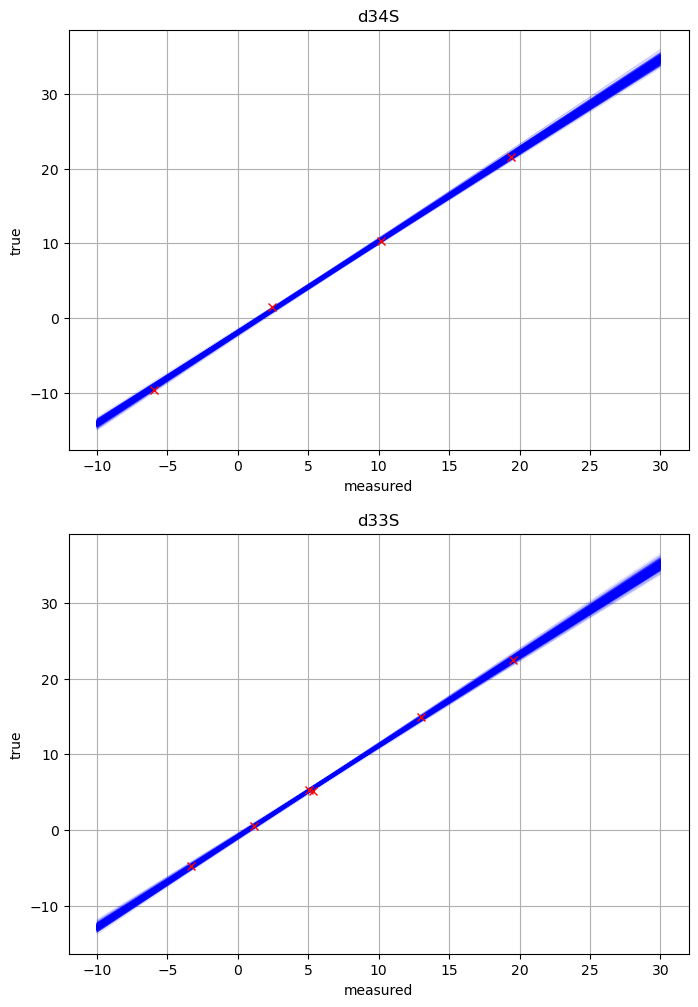

In [83]:
bp='M0'

### Sulphur calibration
slope_33=[];slope_34=[];intercept_33=[];intercept_34=[]

# plot for calib curves
fig,ax=plt.subplots(2,figsize=[8,12])
for axis in ax:
    axis.grid()
    axis.set_xlabel('measured')
    axis.set_ylabel('true')
ax[0].set_title('d34S')
ax[1].set_title('d33S')


for n in range(nn):
    ## 34S  calibration:
    iso='34S'
    # linear regression
    x_data=np.random.normal(stds_stats['mean_d'+iso+'_'+bp],stds_stats['err_d'+iso+'_'+bp])
    y_data=np.random.normal(refs['d'+iso],refs['err_d'+iso])
    [slope, intercept] = calib_regression(x_data,y_data)  
    # store values in lists
    slope_34+=[slope[0]]
    intercept_34+=[intercept[0]]

    # calibrate standard 34S values - 
    d34_cal =  (stds_stats['mean_d'+iso+'_'+bp]+1)**slope * (intercept +1)-1
    
    # add line to plot
    x=np.array([-10,30])*1e-3
    y= ( (1+x)**slope*(1+intercept)-1 )
    ax[0].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=0.2)


    # 33S linear calibration based on known D33S values
    iso = '33S'   
    D_values = pd.Series(np.random.normal(refs['D33S'].dropna(), refs['err_D33S'].dropna()), index=refs['D33S'].dropna().index)
    #  calculate d33 values for VS, based on calibrated measurements and known D33S.
    d_calc_stds = pd.Series(index=stds_stats.index).rename_axis('sample_name')
    for std in [std for std in stds_stats.index if std in D_values.index]:
        d_calc_stds.loc[std] = D_values.loc[std] + ((1+d34_cal.loc[std])**0.515-1)
    if False:
        print('True',iso, 'calculated for standards, based on calibrated measurements and known D33S:\n',d_calc_stds*1e3)
    # regression
    x_data=np.random.normal(stds_stats['mean_d33S_M0'],stds_stats['err_d33S_M0'])
    y_data=np.random.normal(d_calc_stds,0)

    [slope, intercept] = calib_regression(x_data,y_data)  
    # store values in lists 
    slope_33+=[slope[0]]
    intercept_33+=[intercept[0]]
    
    # add line to plot
    x=np.array([-10,30])*1e-3
    y= ( (1+x)**slope*(1+intercept)-1 )
    ax[1].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=0.2)
    
    
    # CALIBRATE STDS and SAMPLES
    stds_stats_pet=pd.DataFrame(index=stds_stats.index)
    stds_stats_pet['mean_d34S_M0'] = np.random.normal(stds_stats['mean_d34S_M0'],stds_stats['err_d34S_M0'])
    stds_stats_pet['mean_d33S_M0'] = np.random.normal(stds_stats['mean_d33S_M0'],stds_stats['err_d33S_M0'])
    for row in stds_cal.index:
        stds_cal.loc[row,'d34S_M0'] += [(stds_stats_pet.loc[row,'mean_d34S_M0']+1)**slope_34[-1] * (intercept_34[-1] +1)-1]
        stds_cal.loc[row,'d33S_M0'] += [(stds_stats_pet.loc[row,'mean_d33S_M0']+1)**slope_33[-1] * (intercept_33[-1] +1)-1]
        stds_cal.loc[row,'D33S_M0'] += [(stds_stats_pet.loc[row,'mean_d33S_M0']+1)**slope_33[-1] * (intercept_33[-1] +1)-1 - ( ((stds_stats_pet.loc[row,'mean_d34S_M0']+1)**slope_34[-1] * (intercept_34[-1] +1))**0.515 -1 ) ]
    
    samples_pet=pd.DataFrame(index=samples.index)
    samples_pet['mean_d34S_M0'] = np.random.normal(samples['mean_d34S_M0'],samples['err_d34S_M0'])
    samples_pet['mean_d33S_M0'] = np.random.normal(samples['mean_d33S_M0'],samples['err_d33S_M0'])
    for row in samples.index:
        samples_cal.loc[row,'d34S_M0'] += [(samples_pet.loc[row,'mean_d34S_M0']+1)**slope_34[-1] * (intercept_34[-1] +1)-1]
        samples_cal.loc[row,'d33S_M0'] += [(samples_pet.loc[row,'mean_d33S_M0']+1)**slope_33[-1] * (intercept_33[-1] +1)-1]
        samples_cal.loc[row,'D33S_M0'] += [(samples_pet.loc[row,'mean_d33S_M0']+1)**slope_33[-1] * (intercept_33[-1] +1)-1 - ( ((samples_pet.loc[row,'mean_d34S_M0']+1)**slope_34[-1] * (intercept_34[-1] +1))**0.515 -1 ) ]
    
ax[0].errorbar(stds_stats['mean_d34S_M0']*1e3,refs['d34S']*1e3,
                   c='r',linestyle='none',marker='x')  
# d33S points - calc
d33S_stds_calc = refs['D33S']+0.515*np.array([np.mean(stds_cal.loc[std,'d34S_M0']) for std in stds_cal.index])
ax[1].errorbar(stds_stats['mean_d33S_M0']*1e3,d33S_stds_calc*1e3,
                   c='r',linestyle='none',marker='x')    


print('Mean intercept d34S:', f"{np.mean(intercept_34)*1e3:.2f}")
print('Mean slope d34S:', f"{np.mean(slope_34):.2f}")
print('Mean intercept d33S:', f"{np.mean(intercept_33)*1e3:.2f}")
print('Mean slope d33S:', f"{np.mean(slope_33):.2f}")

### M0 d18O and d17O calibrations

Mean intercept d18O: 9.19
Mean slope d18O: 1.41
Mean intercept d17O: 4.61
Mean slope d17O: 1.16


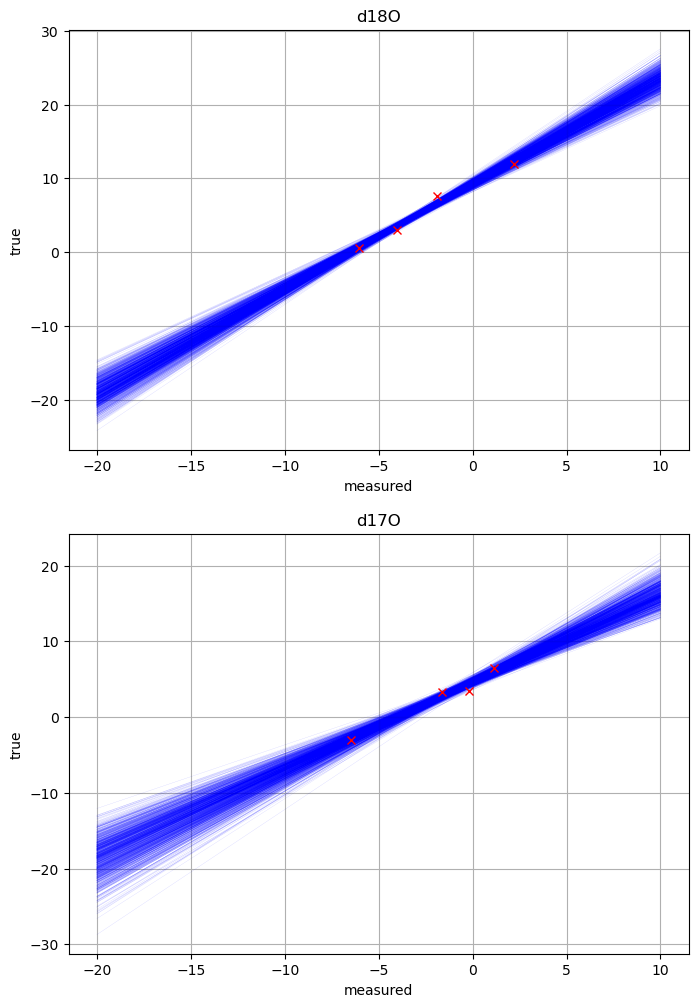

In [84]:
### Oxygen calibration

slope_17=[];slope_18=[];intercept_17=[];intercept_18=[]

# for calib curves
fig,ax=plt.subplots(2,figsize=[8,12])
for axis in ax:
    axis.grid()
    axis.set_xlabel('measured')
    axis.set_ylabel('true')
ax[0].set_title('d18O')
ax[1].set_title('d17O')



for n in range(nn):
    ## 18O  calibration:
    iso='18O'
    # linear regression
    x_data=np.random.normal(stds_stats['mean_d'+iso+'_'+bp],stds_stats['err_d'+iso+'_'+bp])
    y_data=np.random.normal(refs['d'+iso],refs['err_d'+iso])
    # call to regression func
    [slope, intercept] = calib_regression(x_data,y_data)  
    # store values in lists
    slope_18+=[slope[0]]
    intercept_18+=[intercept[0]]

    # calibrate standard 18O values - 
    d18_cal =  (stds_stats['mean_d'+iso+'_'+bp]+1)**slope * (intercept +1)-1
    
    # add line to plot
    x=np.array([-20,10])*1e-3
    y= ( (1+x)**slope*(1+intercept)-1 )
    ax[0].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=0.2)


    # 17O linear calibration based on known D17O values
    iso = '17O'   
    D_values = pd.Series(np.random.normal(refs['D17O'].dropna(), refs['err_D17O'].dropna()), index=refs['D17O'].dropna().index)
    #  calculate d33 values for standards, based on calibrated measurements and known D33S.
    d_calc_stds = pd.Series(index=stds_stats.index).rename_axis('sample_name')
    for std in [std for std in stds_stats.index if std in D_values.index]:
        d_calc_stds.loc[std] = D_values.loc[std] + 0.52 * d18_cal.loc[std]
    if False:
        print('True',iso, 'calculated for standards, based on calibrated measurements and known D17O:\n',d_calc_stds*1e3)
    # regression
    x_data=np.random.normal(stds_stats['mean_d17O_M0'],stds_stats['err_d17O_M0'])
    y_data=np.random.normal(d_calc_stds,0)
    [slope, intercept] = calib_regression(x_data,y_data)  
    # store values in lists 
    slope_17+=[slope[0]]
    intercept_17+=[intercept[0]]
    
    # add line to plot
    x=np.array([-20,10])*1e-3
    y= ( (1+x)**slope*(1+intercept)-1 )
    ax[1].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=0.2)
    
    
    # CALIBRATE STDS and SAMPLES
    stds_stats_pet=pd.DataFrame(index=stds_stats.index)
    stds_stats_pet['mean_d18O_M0'] = np.random.normal(stds_stats['mean_d18O_M0'],stds_stats['err_d18O_M0'])
    stds_stats_pet['mean_d17O_M0'] = np.random.normal(stds_stats['mean_d17O_M0'],stds_stats['err_d17O_M0'])
    for row in stds_cal.index:
        stds_cal.loc[row,'d18O_M0'] += [(stds_stats_pet.loc[row,'mean_d18O_M0']+1)**slope_18[-1] * (intercept_18[-1] +1)-1]
        stds_cal.loc[row,'d17O_M0'] += [(stds_stats_pet.loc[row,'mean_d17O_M0']+1)**slope_17[-1] * (intercept_17[-1] +1)-1]
        stds_cal.loc[row,'D17O_M0'] += [(stds_stats_pet.loc[row,'mean_d17O_M0']+1)**slope_17[-1] * (intercept_17[-1] +1)-1 - 0.52*((stds_stats_pet.loc[row,'mean_d18O_M0']+1)**slope_18[-1]* (intercept_18[-1] +1)-1) ]
    
    samples_pet=pd.DataFrame(index=samples.index)
    samples_pet['mean_d18O_M0'] = np.random.normal(samples['mean_d18O_M0'],samples['err_d18O_M0'])
    samples_pet['mean_d17O_M0'] = np.random.normal(samples['mean_d17O_M0'],samples['err_d17O_M0'])
    for row in samples.index:
        samples_cal.loc[row,'d18O_M0'] += [(samples_pet.loc[row,'mean_d18O_M0']+1)**slope_18[-1] * (intercept_18[-1] +1)-1]
        samples_cal.loc[row,'d17O_M0'] += [(samples_pet.loc[row,'mean_d17O_M0']+1)**slope_17[-1] * (intercept_17[-1] +1)-1]
        samples_cal.loc[row,'D17O_M0'] += [(samples_pet.loc[row,'mean_d17O_M0']+1)**slope_17[-1] * (intercept_17[-1] +1)-1 - 0.52*((samples_pet.loc[row,'mean_d18O_M0']+1)**slope_18[-1] * (intercept_18[-1] +1)-1) ]
    
# add points for standards    
ax[0].errorbar(stds_stats['mean_d18O_M0']*1e3,refs['d18O']*1e3,
                   c='r',linestyle='none',marker='x')
# d17O points - calc
d17O_stds_calc = refs['D17O']+0.52*np.array([np.mean(stds_cal.loc[std,'d18O_M0']) for std in stds_cal.index])
ax[1].errorbar(stds_stats['mean_d17O_M0']*1e3,d17O_stds_calc*1e3,
                   c='r',linestyle='none',marker='x')    

mean_metadata_M0 = {'Intercept 34S':np.mean(intercept_34),
                    'Slope 34S':np.mean(slope_34),
                    'Intercept 33S':np.mean(intercept_33),
                    'Slope 33S':np.mean(slope_33),
                    'Intercept 18O':np.mean(intercept_18),
                    'Slope 18O':np.mean(slope_18),
                    'Intercept 17O':np.mean(intercept_17),
                    'Slope 17O':np.mean(slope_17)}

print('Mean intercept d18O:', f"{np.mean(intercept_18)*1e3:.2f}")
print('Mean slope d18O:', f"{np.mean(slope_18):.2f}")
print('Mean intercept d17O:', f"{np.mean(intercept_17)*1e3:.2f}")
print('Mean slope d17O:', f"{np.mean(slope_17):.2f}")

In [85]:
def averaging(df):
    df2=pd.DataFrame(columns=[col for col in df.columns]+[col+'_err' for col in df.columns], index=df.index)
    for row in df.index:
        for col in df.columns:
            df2.loc[row,col] = np.mean(df.loc[row,col])
            df2.loc[row,col+'_err'] = np.std(df.loc[row,col])
            # df2.loc[row,col] = np.median(df.loc[row,col])
            # df2.loc[row,col+'_err'] = np.percentile(df.loc[row,col],75)-np.percentile(df.loc[row,col],25)
    return df2

samples_cal_final=0; stds_cal_final=0;
samples_cal_final =averaging(samples_cal)
stds_cal_final = averaging(stds_cal)

samples_cal_final*1e3

,d17O_M0,d18O_M0,d33S_M0,d34S_M0,D17O_M0,D33S_M0,d17O_M0_err,d18O_M0_err,d33S_M0_err,d34S_M0_err,D17O_M0_err,D33S_M0_err
DC-01,-7.50,-18.54,9.36,20.64,2.14,-1.22,1.93,1.66,0.48,0.32,1.87,0.49
DC-03,-8.69,-18.16,8.23,18.50,0.75,-1.26,1.77,1.59,0.43,0.35,1.62,0.45
DC-06,-7.47,-19.30,9.22,19.27,2.57,-0.66,2.19,2.01,0.59,0.41,2.18,0.61
DC-09,-7.36,-17.11,8.93,19.05,1.54,-0.83,1.61,1.55,0.51,0.30,1.48,0.52
DC-12,-5.68,-15.35,7.50,17.45,2.30,-1.45,1.98,1.44,0.45,0.60,1.86,0.53
DC-16,-4.28,-9.94,5.08,13.21,0.89,-1.70,1.63,1.21,0.58,0.26,1.58,0.58
DC-18-20,-4.20,-12.02,3.50,9.02,2.05,-1.14,1.36,1.40,0.51,0.44,1.32,0.54
DC-21-24,-1.58,-5.11,4.07,10.36,1.08,-1.25,1.30,0.96,0.61,0.40,1.30,0.64
DC-27-28,-3.78,-8.14,3.74,8.81,0.45,-0.79,1.35,1.00,0.43,0.32,1.26,0.45
DC-30,-2.52,-7.13,5.38,11.69,1.19,-0.62,1.34,1.27,0.48,0.31,1.38,0.49


### Calculate and display pooled uncertainties pre-and post-calibration

Calculation: 

#### $\sqrt{\frac{\sum \sigma_\delta^2}{n}}$

For standard error $\sigma_\delta$ on $\delta$-values, for $n$ different samples

In [86]:
# calculation pooled error after calib
cols = [ col for col in samples_cal_final.columns if col.endswith('err')]
rows = [ row  for row in samples_cal_final.index if not row.startswith(tuple(stds_dict.values()))]
errs = samples_cal_final.loc[rows,cols]
# Compute post-calibration pooled error
pooled_err_postcalib = pd.DataFrame(
    (np.sum(errs**2, axis=0) / len(errs.index))**0.5,
    columns=['Pooled error post-calibration'])
# Clean up indices
pooled_err_postcalib.index = [s[:-4] for s in pooled_err_postcalib.index]
pooled_err_precalib2 = pooled_err_precalib.copy()
pooled_err_precalib2 = pd.DataFrame(
    pooled_err_precalib2,
    columns=['Pooled error pre-calibration'])
pooled_err_precalib2.index = [s[4:] for s in pooled_err_precalib2.index]

# Merge the two df
pooled_errs = pd.DataFrame()
pooled_errs['Pooled error pre-calibration']=pooled_err_precalib2['Pooled error pre-calibration']
pooled_errs['Pooled error post-calibration']=pooled_err_postcalib['Pooled error post-calibration']

# display 
print('Pooled errors:')
pooled_errs * 1e3

Pooled errors:


,Pooled error pre-calibration,Pooled error post-calibration
d17O_M0,1.10,1.64
d18O_M0,0.54,1.43
d33S_M0,0.41,0.50
d34S_M0,0.26,0.38


## Compilation into single DataFrame, pooled final uncertainties
Reports values for:

- (d15N, D17O, d18O) if M0-only

- Averaged (d15N, D17O, d18O, D15N18O, D18O18O) if M0+noM0

In [87]:
data_summary = samples_cal_final[[col for col in samples_cal_final if col.startswith(('d34','D33','d18','D17'))]]
    
# calculation pooled error for raw deltas
cols = [ col for col in data_summary.columns if col.endswith('err')]
rows = [ row  for row in data_summary.index if not row.startswith(tuple(stds_dict.values()))]
errs = data_summary.loc[rows,cols]
pooled_err_final = (np.sum(errs**2,axis=0)/len(errs.index))**0.5
print('Pooled final errors\n',pooled_err_final*1e3)

# display
print('\nFinal, calibrated delta- and Delta-values')
data_summary[[col for col in data_summary.columns if not col.endswith('_err')]]*1e3


Pooled final errors
 d18O_M0_err   1.43
d34S_M0_err   0.38
D17O_M0_err   1.58
D33S_M0_err   0.53
dtype: object

Final, calibrated delta- and Delta-values


,d18O_M0,d34S_M0,D17O_M0,D33S_M0
DC-01,-18.54,20.64,2.14,-1.22
DC-03,-18.16,18.50,0.75,-1.26
DC-06,-19.30,19.27,2.57,-0.66
DC-09,-17.11,19.05,1.54,-0.83
DC-12,-15.35,17.45,2.30,-1.45
DC-16,-9.94,13.21,0.89,-1.70
DC-18-20,-12.02,9.02,2.05,-1.14
DC-21-24,-5.11,10.36,1.08,-1.25
DC-27-28,-8.14,8.81,0.45,-0.79
DC-30,-7.13,11.69,1.19,-0.62


## Plot final values

/var/folders/rr/bz6rnlcn09b6b2ttxx8h8x5m0000gn/T/ipykernel_78445/737178322.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


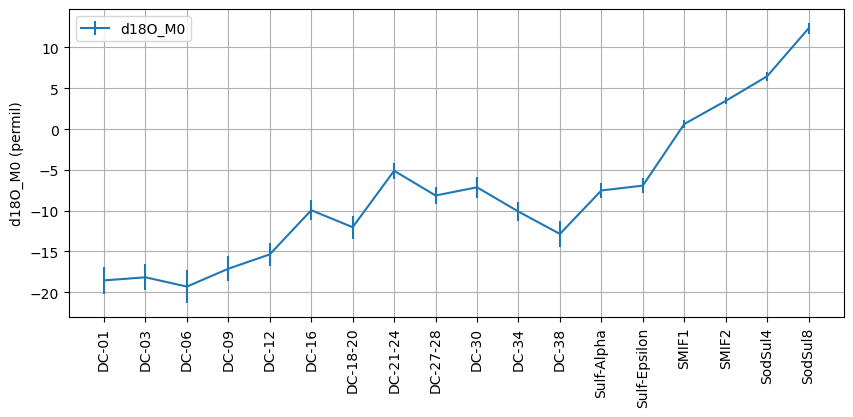

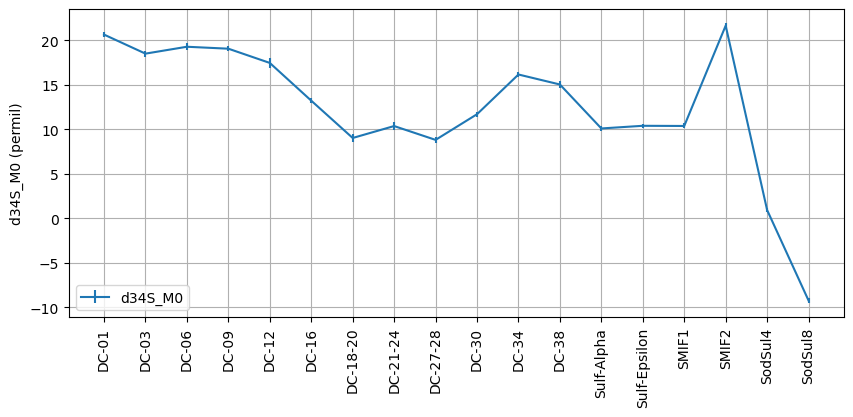

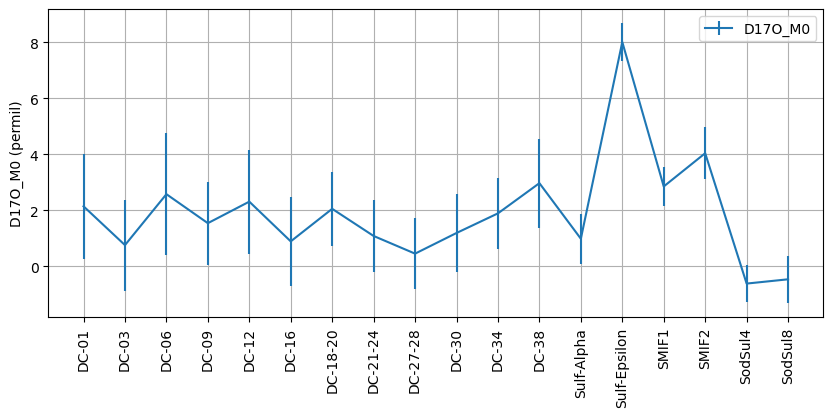

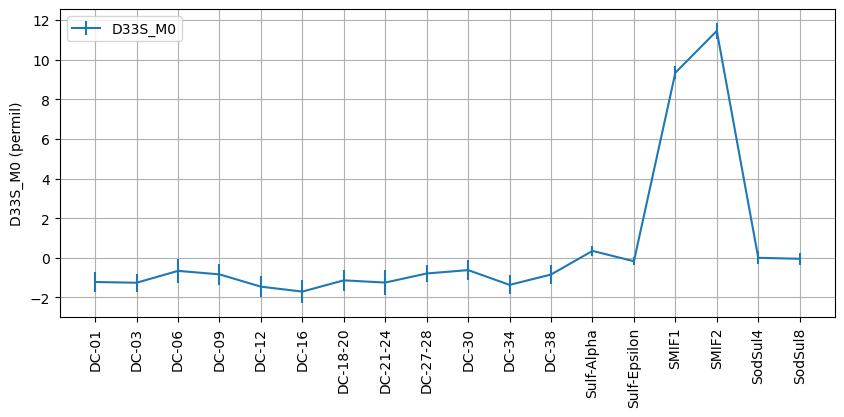

In [88]:
# plots of final summary deltas

# True = plots only samples, False = plots standards also
if False:
    data_plot = data_summary.loc[[row for row in data_summary.index if not row.startswith(tuple(stds_dict.values()))]]
else:
    data_plot = data_summary
    
cols = pd.Series([col for col in data_plot.columns if not col.endswith('_err')]).unique()
    
# plots for each delta
for delta in cols:
    fig,ax=plt.subplots(figsize=[10,4])
    ax.errorbar(x=data_plot.index, y=data_plot[delta]*1e3,
               yerr=data_plot[delta+'_err']*1e3, label=delta)
   
    ax.set_ylabel(delta+' (permil)')
    ax.grid()
    ax.legend()
    ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

## Save all steps to excel file

In [90]:
output_file = os.getcwd().split('/')[-1]+'_calibrated_'+data_type+'_'+current_date_string+'.xlsx'

if data_type=='M0+noM0':
    to_save = {'Small deltas uncalibrated':samples,
               'Small deltas calibrated':samples_cal_final,
               'Small deltas M0 calculations':small_deltas,
               'Derived deltas':derived_deltas,
               'Reported deltas':data_summary,
               'Calibration metadata M0': pd.DataFrame(mean_metadata_M0.items()),
              'Calibration metadata no-M0': pd.DataFrame(mean_metadata_noM0.items()),
              'Pooled errors': pooled_errs}
else:
    to_save = {'Small deltas uncalibrated':samples,
               'Small deltas calibrated':samples_cal_final,
               'Reported deltas':data_summary,
               'Calibration metadata M0': pd.DataFrame(mean_metadata_M0.items()),
              'Pooled errors': pooled_errs}

for sheet_name, df in to_save.items():
    # Check if the file exists
    if not os.path.exists(os.path.join(output_file)):
        # If the file doesn't exist, create a new ExcelWriter object without mode='a'
        with pd.ExcelWriter(os.path.join(output_file), engine='openpyxl') as writer:
            # Write the DataFrame to a new sheet with the specified sheet name
            df.to_excel(writer, sheet_name=sheet_name, index=True)
            print('Excel file created:',os.path.join(output_file),'\nNew sheet added to',output_file,':',sheet_name)
    else:
        # If the file exists, create an ExcelWriter object with mode='a' to append to the existing file
        with pd.ExcelWriter(os.path.join(output_file), engine='openpyxl', mode='a',if_sheet_exists='replace') as writer:
            # Write the DataFrame to a new sheet with the specified sheet name
            df.to_excel(writer, sheet_name=sheet_name, index=True)
            print('New sheet added to',output_file,':',sheet_name)

New sheet added to DC-2011-2_HSO4_M0_calibrated_M0-only_2025-07-17.xlsx : Small deltas uncalibrated
New sheet added to DC-2011-2_HSO4_M0_calibrated_M0-only_2025-07-17.xlsx : Small deltas calibrated
New sheet added to DC-2011-2_HSO4_M0_calibrated_M0-only_2025-07-17.xlsx : Reported deltas
New sheet added to DC-2011-2_HSO4_M0_calibrated_M0-only_2025-07-17.xlsx : Calibration metadata M0
New sheet added to DC-2011-2_HSO4_M0_calibrated_M0-only_2025-07-17.xlsx : Pooled errors
